In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Loading `SubChar` Tokenizer

In this notebook, I explore the paper "Sub-Character Tokenization for Chinese Pretrained Language Models" by C. Si et al.

The authors propose a methodology to tokenize Chinese texts using sub-character components. These components can be either pronunciation based (*pinyin*, or *zhuyin*) or glyph based (*Wubi*, *Cangjie*, *Zhengma*, *Stroke*).

My goal is to explore the implementation of the *Wubi* tokenizer to find applications for my analysis. I select *Wubi* as the main model, since the method maps Latin letters to Chinese radicals directly without need to identify logical combinations (as in the case of *stroke*). *Cangjie* and *Zhengma* would also be suitable, but I select *Wubi* as the paper provides examples using this transliteration.

Load repository:

In [2]:
!git clone https://github.com/thunlp/SubCharTokenization.git
%cd SubCharTokenization

Cloning into 'SubCharTokenization'...
remote: Enumerating objects: 403, done.
remote: Counting objects: 100% (403/403), done.
remote: Compressing objects: 100% (313/313), done.
remote: Total 403 (delta 93), reused 392 (delta 83), pack-reused 0 (from 0)
Receiving objects: 100% (403/403), 31.16 MiB | 19.29 MiB/s, done.
Resolving deltas: 100% (93/93), done.
/kaggle/working/SubCharTokenization


## Wubi + Pre-trained SentencePiece

The authors proposed to split individual characters into sequences of *Wubi* symbols and further merge subchars and characters.

In [3]:
import pickle
import sentencepiece as spm
import unicodedata

class WubiTokenizer:
    """
    Wubi (五笔) SubChar tokenizer following the original SubCharTokenization code.
    Maps each Chinese character to its Wubi code, inserts a separator between characters,
    and then applies SentencePiece subword segmentation.
    """
    def __init__(self, wubi_dict_path, sp_model_path):
        # Load character -> Wubi mapping (pickled dict)
        with open(wubi_dict_path, 'rb') as f:
            self.ch2wubi = pickle.load(f)

        # Load SentencePiece model
        self.sp = spm.SentencePieceProcessor()
        self.sp.Load(sp_model_path)

        # Separator used after each character's Wubi code (same as original)
        self.sep = chr(ord('_') + 50000)

        # Punctuation mapping (from original code)
        self.ch2en_punc = {
            '，': ',', '。': '.', '！': '!', '？': '?', '【': '[', '】': ']',
            '（': '(', '）': ')', '％': '%', '＃': '#', '＠': '@', '＆': '&',
            '１': '1', '２': '2', '３': '3', '４': '4', '５': '5', '６': '6',
            '７': '7', '８': '8', '９': '9', '０': '0', '；': ';', '：': ':'
        }

    def _convert_char(self, ch):
        """Convert a single character to its Wubi code (or fallback)."""
        # Normalize punctuation
        if ch in self.ch2en_punc:
            ch = self.ch2en_punc[ch]
        # If character has a Wubi code, return it (original strips digits)
        if ch in self.ch2wubi:
            # Some codes contain digits (e.g., for tone), but original strips them
            # We'll keep as-is; the mapping values are usually letters only.
            return self.ch2wubi[ch].strip()
        # Fallback: use the character itself
        return ch

    def tokenize(self, text, return_spans=True):
        """
        Tokenize a Chinese text into subword token IDs.
        Args:
            text: string (e.g., "你好世界")
            return_spans: if True, also returns a list of (start, end) token indices
                          for each original character.
        Returns:
            token_ids: list of int (subword token IDs)
            char_spans: (optional) list of (start, end) tuples, one per character
        """
        text = text.lower()  # original code lowercases everything
        chars = list(text)

        # Step 1: build the Wubi‑encoded string with separators
        encoded_parts = []
        for ch in chars:
            code = self._convert_char(ch)
            encoded_parts.append(code)
            encoded_parts.append(self.sep)
        encoded_str = ''.join(encoded_parts)

        print(encoded_str)

        # Step 2: run SentencePiece to get token IDs for the whole sequence
        full_ids = self.sp.EncodeAsIds(encoded_str)

        if not return_spans:
            return full_ids

        # Step 3: compute character spans by tokenizing each character's block separately
        char_spans = []
        current_pos = 0
        for ch in chars:
            code = self._convert_char(ch)
            # Build the block for this single character (code + separator)
            block = code + self.sep
            # Tokenize this block (SentencePiece may split it into multiple subwords)
            block_ids = self.sp.EncodeAsIds(block)
            start = current_pos
            end = current_pos + len(block_ids)
            char_spans.append((start, end))
            current_pos = end

        return full_ids, char_spans

    def decode(self, token_ids):
        """Convert token IDs back to readable text (for debugging)."""
        return self.sp.DecodeIds(token_ids)

In [4]:
# Paths to the files from the SubCharTokenization repository
wubi_dict = "data/chinese_to_wubi.pkl"
sp_model = "tokenizers/wubi_no_index_22675.model"

tokenizer = WubiTokenizer(wubi_dict, sp_model)

text = "我是最高的学生"
ids, spans = tokenizer.tokenize(text)

print("Token IDs:", ids)
print("Character spans:", spans)   # e.g., [(0,2), (2,4), (4,6), (6,8)]

# You can later average hidden states for each character using these spans.

q쎯j쎯jb쎯ym쎯r쎯ip쎯tg쎯
Token IDs: [274, 12, 9184, 336]
Character spans: [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7)]


In [5]:
tokens = [tokenizer.sp.IdToPiece(id) for id in ids]
tokens

['q쎯', 'j쎯', 'jb쎯ym쎯r쎯', 'ip쎯tg쎯']

The tokenizer learnt to join characters together, the output sequence of corresponds to the tokens: 我，是，最高的，学生. Perfect from the part-of-speech point of view as the tokenizer sees the correct word boundaries. However, the goal of my study is to rather treat individual components of each characters, such as 人 in 认，心 in 总, called *radicals*, and possibly merge some of them.

Therefore, let's drop the work of SentencePiece and use only Wubi:

## Wubi only

In [6]:
import pickle
import torch

class WubiCharTokenizer:
    """
    Tokenizes Chinese text into sequences of atomic Wubi symbols (letters + separator).
    Each character becomes a fixed number of tokens (its Wubi code letters + separator).
    No merging across characters occurs.
    """
    def __init__(self, wubi_dict_path):
        with open(wubi_dict_path, 'rb') as f:
            self.ch2wubi = pickle.load(f)

        # Build vocabulary: all possible letters + separator
        self.sep = '#'
        letters = set()
        for code in self.ch2wubi.values():
            letters.update(code)
        # Also include digits? Original mapping strips digits, so just letters.
        self.vocab = ['[PAD]', '[UNK]', self.sep] + sorted(letters)
        self.stoi = {s: i for i, s in enumerate(self.vocab)}
        self.itos = {i: s for s, i in self.stoi.items()}

    def encode(self, text):
        """
        Convert text to a list of token IDs and a list of character spans.
        Returns:
            ids: list of int (token IDs)
            char_spans: list of (start, end) token indices for each character
        """
        text = text.lower()
        ids = []
        char_spans = []
        for ch in text:
            # Get Wubi code (fallback to character itself)
            code = self.ch2wubi.get(ch, ch)
            # Convert each symbol in the code to an ID
            code_ids = [self.stoi.get(c, self.stoi['[UNK]']) for c in code]
            start = len(ids)
            ids.extend(code_ids)
            ids.append(self.stoi[self.sep])
            end = len(ids)
            char_spans.append((start, end))
        return ids, char_spans

    def decode(self, ids):
        """For debugging: convert IDs back to string."""
        return ''.join(self.itos[i] for i in ids if i != self.stoi[self.sep])

In [7]:
# Load the Wubi mapping (from the SubCharTokenization repo)
wubi_dict = "data/chinese_to_wubi.pkl"
tokenizer = WubiCharTokenizer(wubi_dict)

text = "我是最高的学生"
ids, spans = tokenizer.encode(text)

print("Token IDs:", ids)
print("Character spans:", spans)
# Output: spans like [(0,5), (5,8), (8,15), ...] depending on code lengths

Token IDs: [29, 2, 22, 2, 22, 14, 2, 37, 25, 2, 30, 2, 21, 28, 2, 32, 19, 2]
Character spans: [(0, 2), (2, 4), (4, 7), (7, 10), (10, 12), (12, 15), (15, 18)]


Reconstruct output to be more informative:

In [8]:
# Inverse mapping from Wubi to Character
with open("data/wubi_to_chinese.pkl", 'rb') as f:
    wubi2ch = pickle.load(f)

In [9]:
def show_tokenization_span(spans):
    print("Char Span: Token Ids (Wubi Code) -> Decoded Char")
    for span in spans:
        low_idx, high_idx = span
    
        # exclude the separator symbol at the end)
        span_ids = ids[low_idx:high_idx-1]
    
        # Convert individual Wubi parts into character

        wubi_code = "".join([tokenizer.itos[idx] for idx in span_ids])
        
        span_char =  wubi2ch[wubi_code]

        print(f"{span}: {span_ids} ({wubi_code}) -> {span_char}")

In [10]:
show_tokenization_span(spans)

Char Span: Token Ids (Wubi Code) -> Decoded Char
(0, 2): [29] (q) -> 我
(2, 4): [22] (j) -> 是
(4, 7): [22, 14] (jb) -> 最
(7, 10): [37, 25] (ym) -> 高
(10, 12): [30] (r) -> 的
(12, 15): [21, 28] (ip) -> 学
(15, 18): [32, 19] (tg) -> 生


Let's look at the tokenization of some characters sharing components:

In [11]:
text = "马吗妈骂"
ids, spans = tokenizer.encode(text)

print("Token IDs:", ids)
print("Character spans:", spans)

Token IDs: [15, 26, 2, 23, 15, 19, 2, 34, 15, 2, 23, 23, 15, 2]
Character spans: [(0, 3), (3, 7), (7, 10), (10, 14)]


In [12]:
show_tokenization_span(spans)

Char Span: Token Ids (Wubi Code) -> Decoded Char
(0, 3): [15, 26] (cn) -> 马
(3, 7): [23, 15, 19] (kcg) -> 吗
(7, 10): [34, 15] (vc) -> 妈
(10, 14): [23, 23, 15] (kkc) -> 骂


The same code `c` is present in all characters. This code corresponds to the component (马) that serves as a phonetic for all characters.

Below I provide the mapping of *Wubi* codes to radicals:

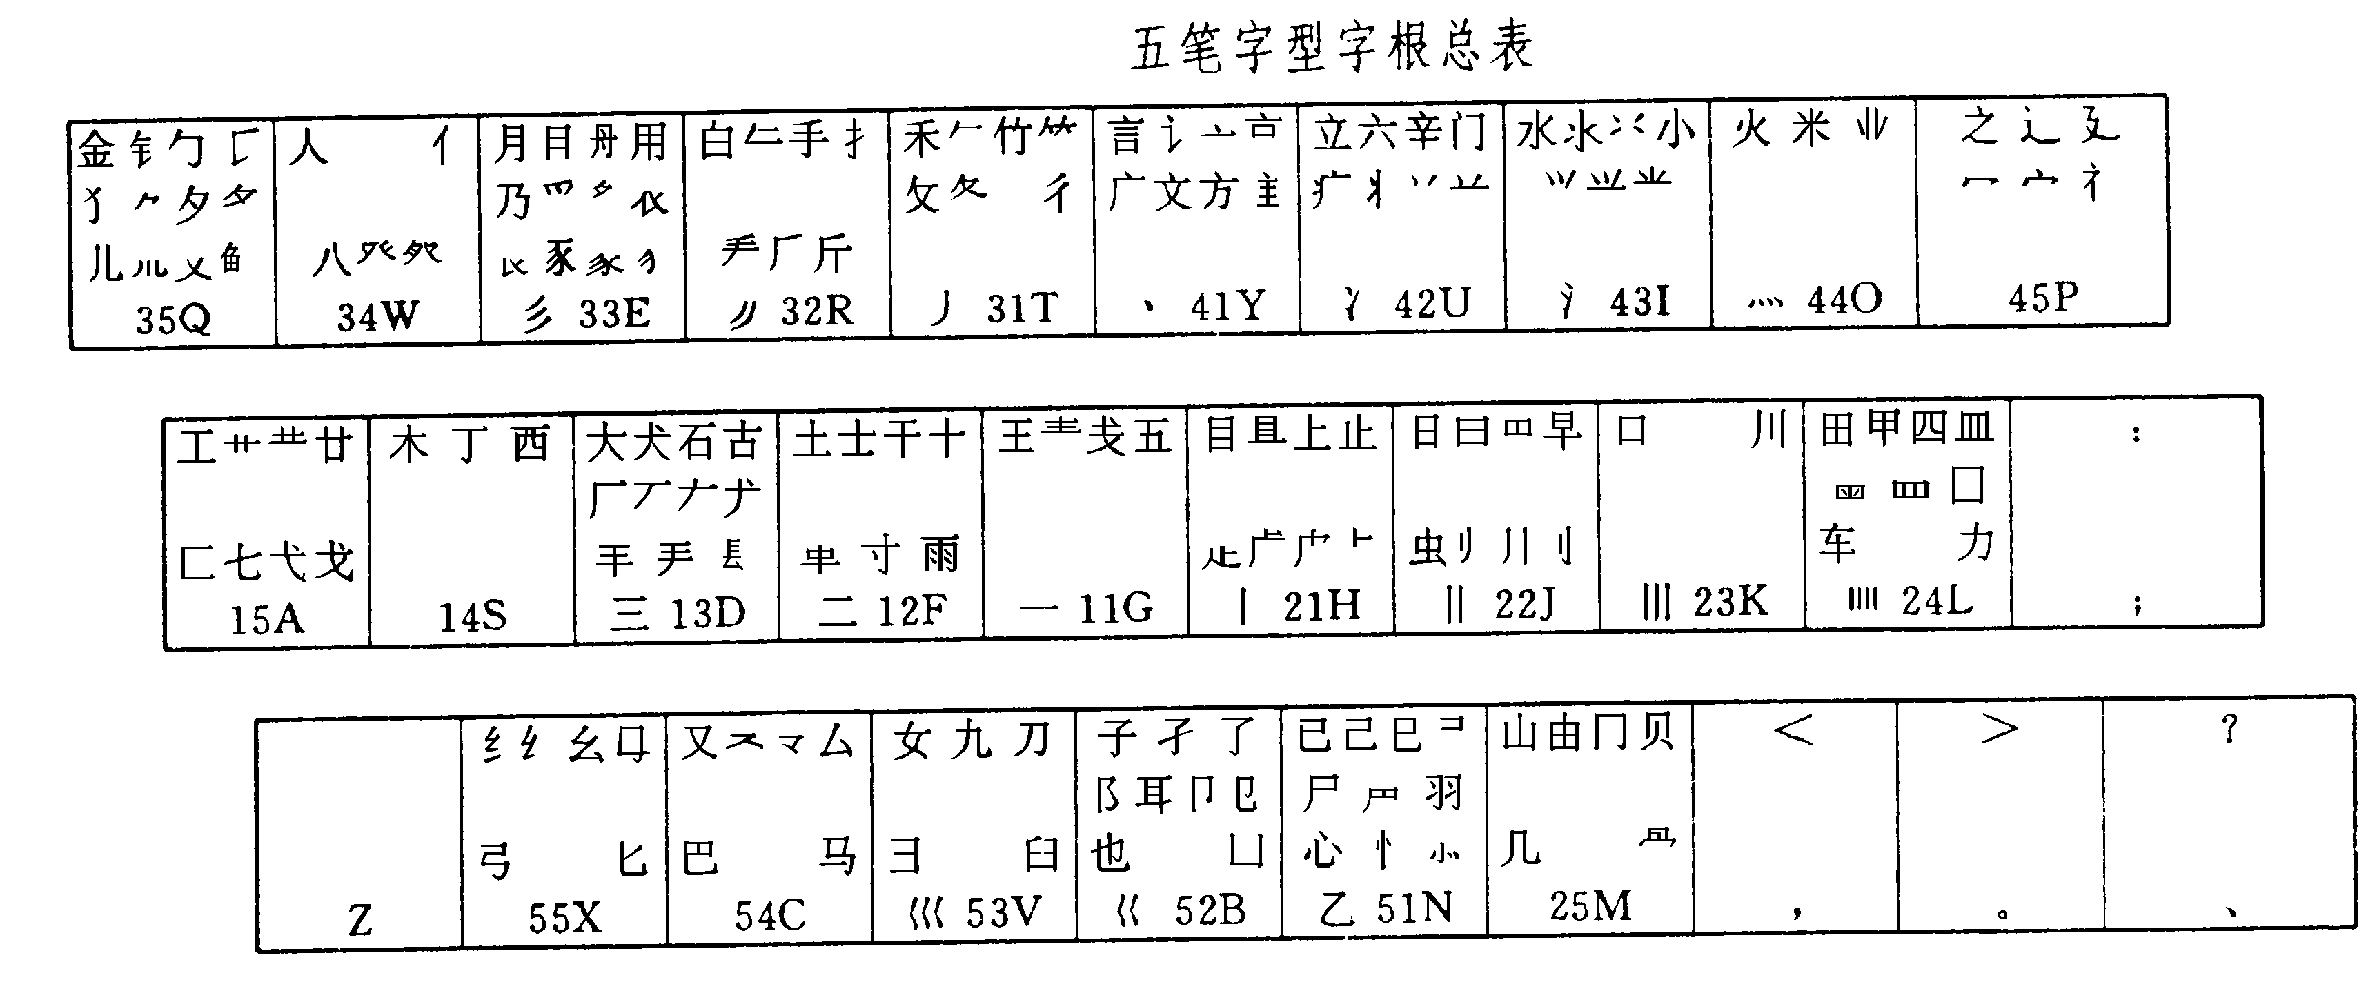
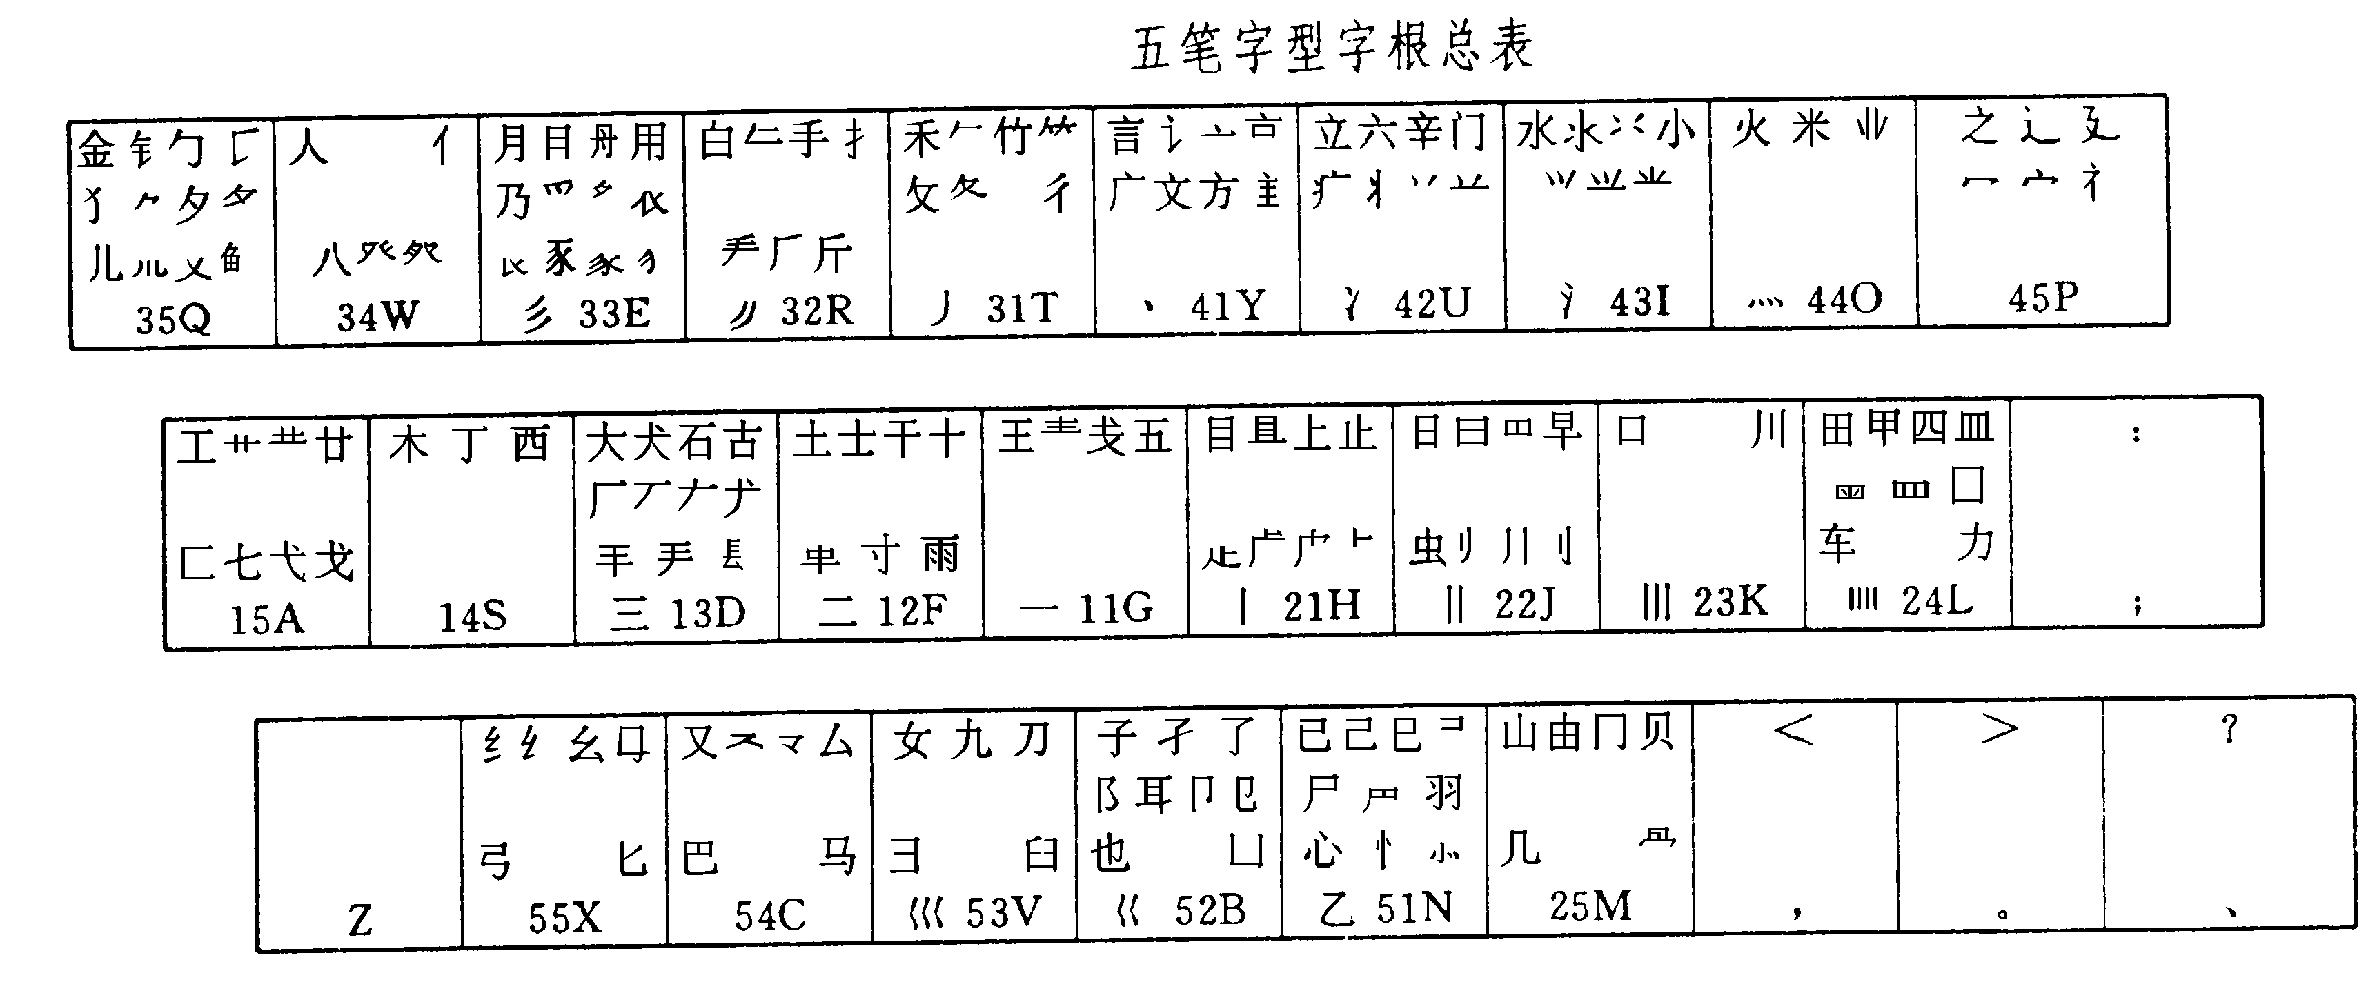

Note that the mapping is not injective (`l` corresponds for both 四 and 车). But do not get confused with the transliteration inverse function: we do not find inverse of each piece in the sequence but rather decode the whole sequence.

So, the characters 四，车 themselves have different codes:

In [13]:
tokenizer.ch2wubi['四'], tokenizer.ch2wubi['车']

('lh', 'lg')

What the table shows is how to decode a composite character containing radicals. For example, 斩 has the component (or radical, for simplicity can be used interchangably) 车.

In [14]:
tokenizer.ch2wubi['斩']

'lr'

Nevertheless, the inverse mapping is not determenistic as many characters share codes for radicals. Moreover, the maximum *Wubi* code is limited to 4, and characters with more than 4 components are trimmed at the tail to have the prefix of size 3 and the last code letter (`输 = 车 ＋ 人 ＋ 一 ＋ 月 ＋刂` but decodes into `lwgej` -> `lwgj`)

The paper addresses this overlap by introducing indexing for the same codes to uniquely map to the character:

In [15]:
wubi2ch['iqy0'], wubi2ch['iqy1']

('㲼', '汐')

## Saving the Work

In [16]:
%cd ../

/kaggle/working


In [17]:
with open("wubi_to_chinese.pkl", 'wb') as f:
    pickle.dump(wubi2ch, f)

In [18]:
with open("chinese_to_wubi.pkl", 'wb') as f:
    pickle.dump(tokenizer.ch2wubi, f)

# References

[1] Chenglei Si et al., "Sub-Character Tokenization for Chinese Pretrained Language Models," *Transactions of the Association for Computational Linguistics*, 2023. Available. [Online]: [pre-print-link](https://aclanthology.org/2023.tacl-1.28.pdf) 

[2] Joe Wicentowski, "Wubizixing For Speakers of English How to master the most rapid Chinese typing method for computers," 1996. Available. [Online]: [web-page-link](https://www.chinesemac.org/wubi/xing.html)